In [10]:
import os
import glob
import random
from pathlib import Path
import numpy as np
from scipy.stats import kruskal
import pandas as pd
import h5py

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import openslide
from skimage.measure import regionprops_table

import scanpy as sc
import anndata
import leidenalg

import sys
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')
from utils_pheno import * 

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# aggregate all patches derived from NBTs (N: breast cancer patients; N_RM: reduction mammoplasty; N_RRM: risk-reducing mastectomy)
df_comb = pd.read_csv("/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/FoundationModel_features/NBTs_noSampling_combined_dataset.csv")
df_sampled = df_comb.groupby('patient_id').apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)).reset_index(drop=True)

In [18]:
n_neighbors = 15
resolution = 0.5
groupby = f"leiden_{resolution}"
save_prefix = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_atlas'

In [ ]:
# initial Leiden clustering to obtained cleaned dataset 
adata_normal = get_adata(df_sampled)
adata_normal = run_leiden_umap(adata_normal, n_neighbors, resolution)
for i, cluster_id in enumerate(np.unique(adata_normal.obs[groupby])):
    plot_cluster_examples(adata_normal, groupby, cluster_id, sampled_number=5, grid_size=[1, 5], figsize=(12, 2), fontsize=8, save_dir=None, save_patches=False)
exclude_groups = ["5", "7", "8", "9", "10", "11"] 
clean_df = adata_normal.obs[~adata_normal.obs[groupby].isin(exclude_groups)]
clean_df.to_csv("/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/FoundationModel_features/NBT_combined_dataset_clean.csv", index=False)

In [19]:
# load cleaned data
clean_df = pd.read_csv("/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/FoundationModel_features/NBT_combined_dataset_clean.csv")
clean_df["patient_id"] = clean_df["patient_id"].astype(str)
print(f"{len(clean_df)} patches")

for source in np.unique(clean_df['source']):
    unique_patient_ids = np.unique(clean_df[clean_df['source'] == source]['patient_id'])
    print(f"Source: {source}, Unique patient IDs: {len(unique_patient_ids)}")

for source in np.unique(clean_df['source']):
    unique_patient_ids = np.unique(clean_df[clean_df['source'] == source]['wsi_id'])
    print(f"Source: {source}, Unique patient IDs: {len(unique_patient_ids)}")

97276 patches
Source: N, Unique patient IDs: 127
Source: N_RM, Unique patient IDs: 44
Source: N_RRM, Unique patient IDs: 69
Source: N, Unique patient IDs: 432
Source: N_RM, Unique patient IDs: 179
Source: N_RRM, Unique patient IDs: 185


,patch_id,cohort,wsi_id,source,leiden_0.5
0,17027148_FPE_2_12580_1986_92469_86893_99_91_555,KHP,17027148_FPE_2,N_RM,2
1,17027148_FPE_2_12580_1986_92469_86893_62_120_555,KHP,17027148_FPE_2,N_RM,3
2,17027148_FPE_2_12580_1986_92469_86893_104_90_555,KHP,17027148_FPE_2,N_RM,2
3,17027148_FPE_2_12580_1986_92469_86893_79_118_555,KHP,17027148_FPE_2,N_RM,3
4,17027148_FPE_2_12580_1986_92469_86893_150_148_555,KHP,17027148_FPE_2,N_RM,0
...,...,...,...,...,...
97271,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1
97272,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3
97273,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,0
97274,BRACS_773_N_33_2048_512,BRCAS,BRACS_773_N_33,N,1


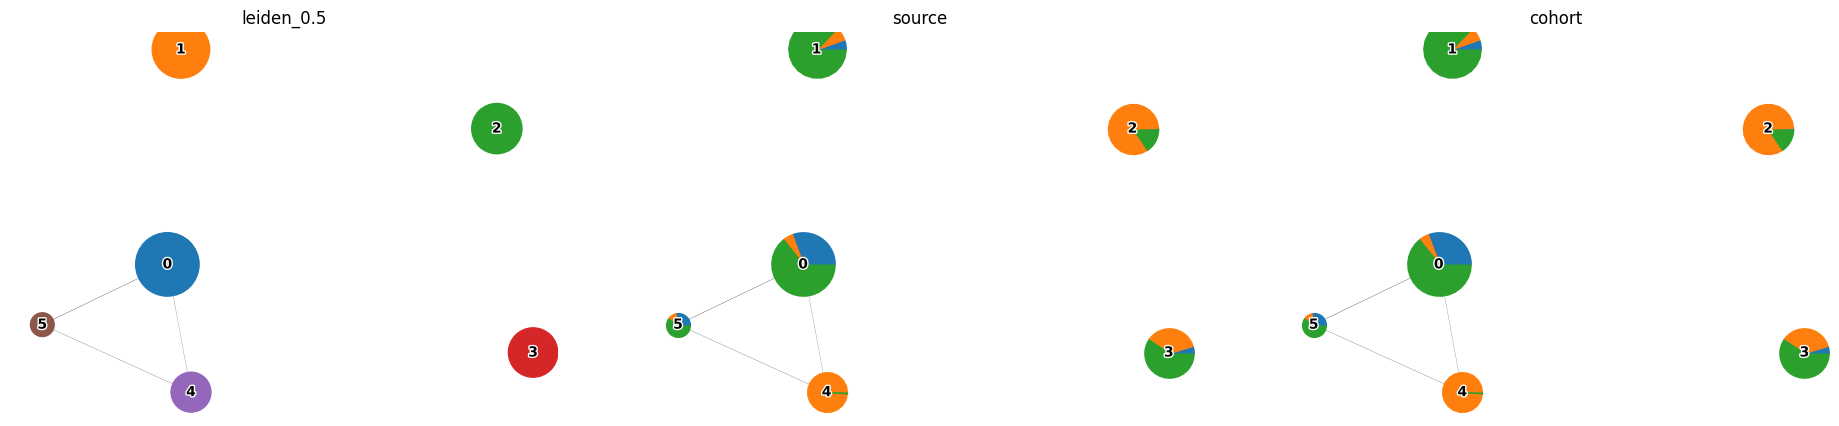

In [20]:
# run Leiden clustering and UMAP
adata_normal = get_adata(clean_df)
adata_normal = run_leiden_umap(adata_normal, n_neighbors, resolution)
adata_normal.obs['cohort'] = adata_normal.obs['cohort'].map({'N_RM': 'KHP', 'N_RRM': 'KHP', 'N': 'BRCAS'})
adata_normal.obs

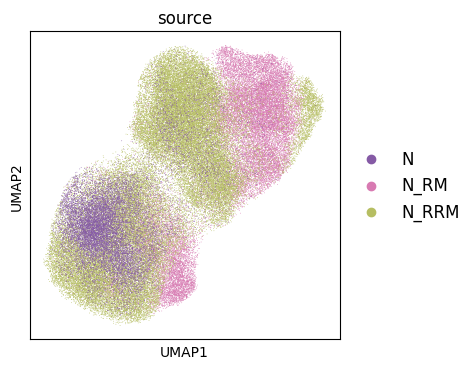

In [5]:
# UMAP visualisation of NBTs of different sources
adata_normal.uns['source_colors'] = ['#855AA5', '#D87AB2', '#B6BE62']
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_normal, color='source', legend_fontsize=12, show=False, ax=axes)
plt.savefig(f'{save_prefix}/{groupby}_umap_source.png', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

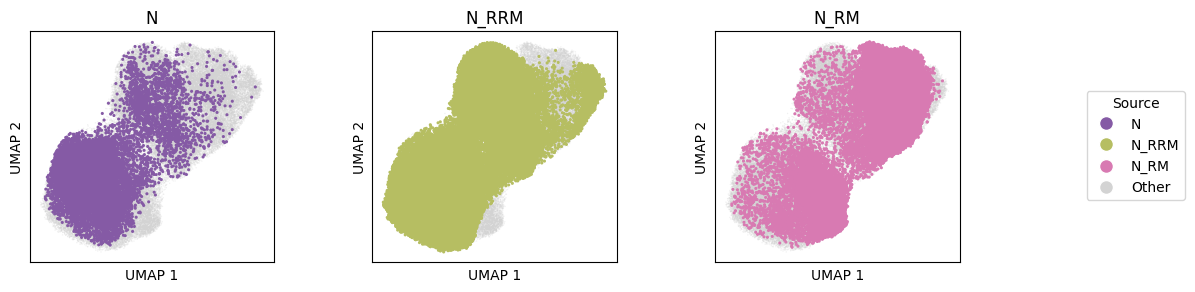

In [7]:
# Separate UMAP visualisation of NBTs of different sources
orders = ['N', 'N_RRM', 'N_RM']
colors = {'N': '#855AA5', 'N_RM': '#D87AB2', 'N_RRM': '#B6BE62', 'other': 'gray'}
save_pt = f'{save_prefix}/{groupby}_umap_source_separate.png'
plot_umap_highlight_each_category(adata_normal, category='source', orders=orders, colors=colors,
                                  max_size=5, min_size=1, fontsize=12,
                                  grid_size=(1, 3), figsize=(12, 3), save_pt=save_pt)

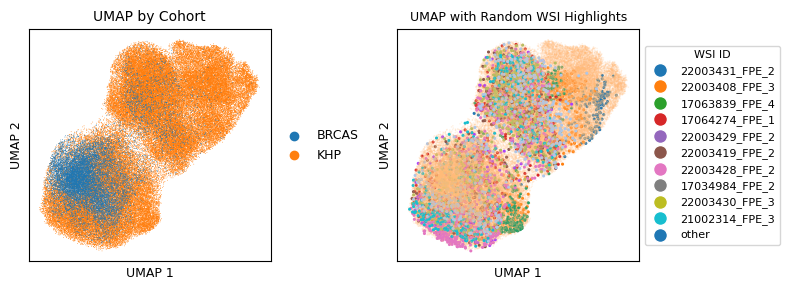

In [72]:
# UMAP visualisation of NBTs from different cohorts and WSIs
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sc.pl.umap(adata_normal, color="cohort", legend_fontsize=12, ax=axes[0], show=False)
axes[0].set_title('UMAP by Cohort', fontsize=10)
axes[0].set_xlabel("UMAP 1", fontsize=9)
axes[0].set_ylabel("UMAP 2", fontsize=9)

plot_umap_with_random_wsi(adata_normal, n_iterations=10, fontsize=8, ax=axes[1])
axes[1].set_title('UMAP with Random WSI Highlights', fontsize=9)
axes[1].set_xlabel("UMAP 1", fontsize=9)
axes[1].set_ylabel("UMAP 2", fontsize=9)

plt.tight_layout()
plt.savefig(f'{save_prefix}/{groupby}_umap_cohort_wsi.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

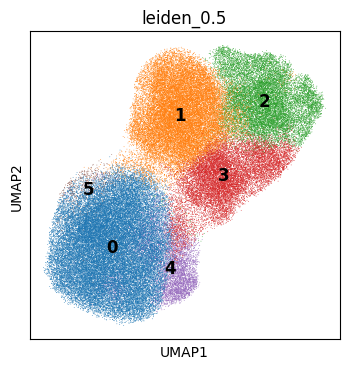

In [73]:
# UMAP visualisation of NBTs grouped as different clusters
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_normal, color=groupby, legend_fontsize=12, legend_loc='on data', show=False, ax=axes)
plt.savefig(f'{save_prefix}/{groupby}_umap_clusters.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

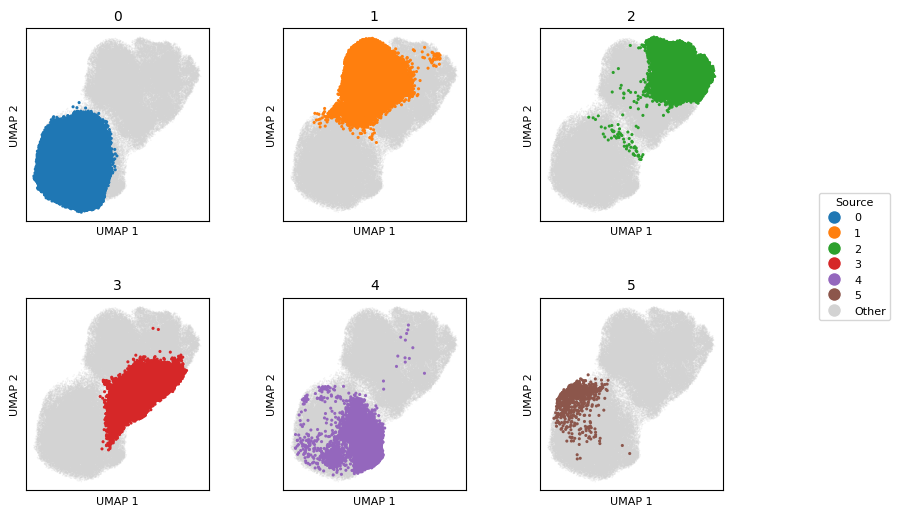

In [74]:
# Separate UMAP visualisation of NBTs grouped as different clusters
orders = ['0', '1', '2', '3', '4', '5']
colors = {'0': adata_normal.uns['leiden_0.5_colors'][0], 
          '1': adata_normal.uns['leiden_0.5_colors'][1],
          '2': adata_normal.uns['leiden_0.5_colors'][2],
          '3': adata_normal.uns['leiden_0.5_colors'][3], 
          '4': adata_normal.uns['leiden_0.5_colors'][4],
          '5': adata_normal.uns['leiden_0.5_colors'][5]}

save_pt = f'{save_prefix}/{groupby}_umap_clusters_separate.pdf'
plot_umap_highlight_each_category(adata_normal, category=groupby, orders=orders, colors=colors, 
                                  max_size=5, min_size=1, fontsize=10,
                                  grid_size=(2, 3), figsize=(9, 6), save_pt=save_pt)

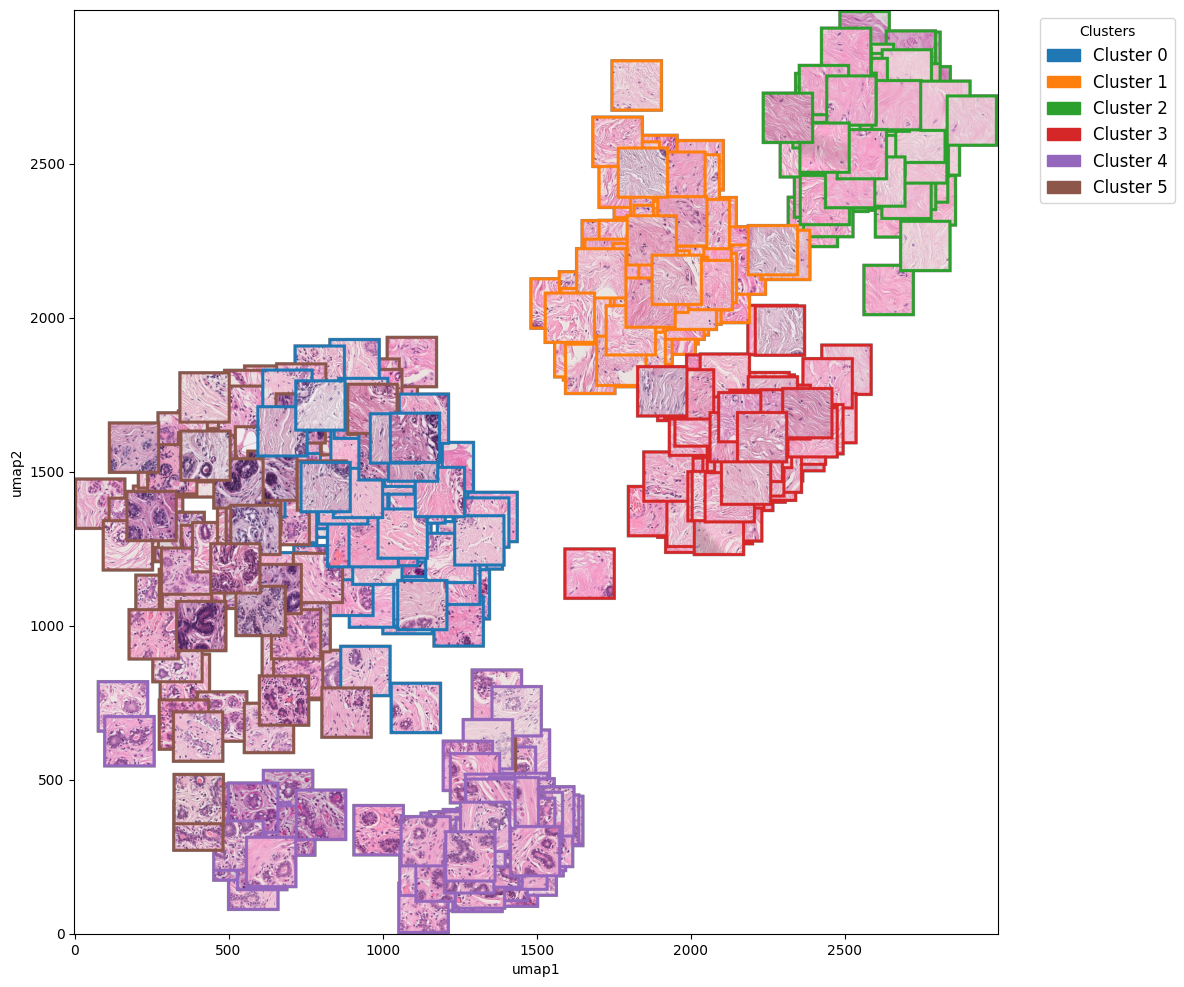

In [23]:
# Obtain top H&E patches of each cluster
adata_normal.obs.index = adata_normal.obs['patch_id']
adata_normal = calculate_top_samples(adata_normal, groupby, top_n=100)


# H&E overlay of the UMAP
save_pt = f'{save_prefix}/{groupby}_umap_HEovrelay.pdf'
full_img = tsne_HE_overlay(adata_normal, groupby='leiden_0.5', image_size=(3000, 3000), max_dim=150, save_pt=save_pt)

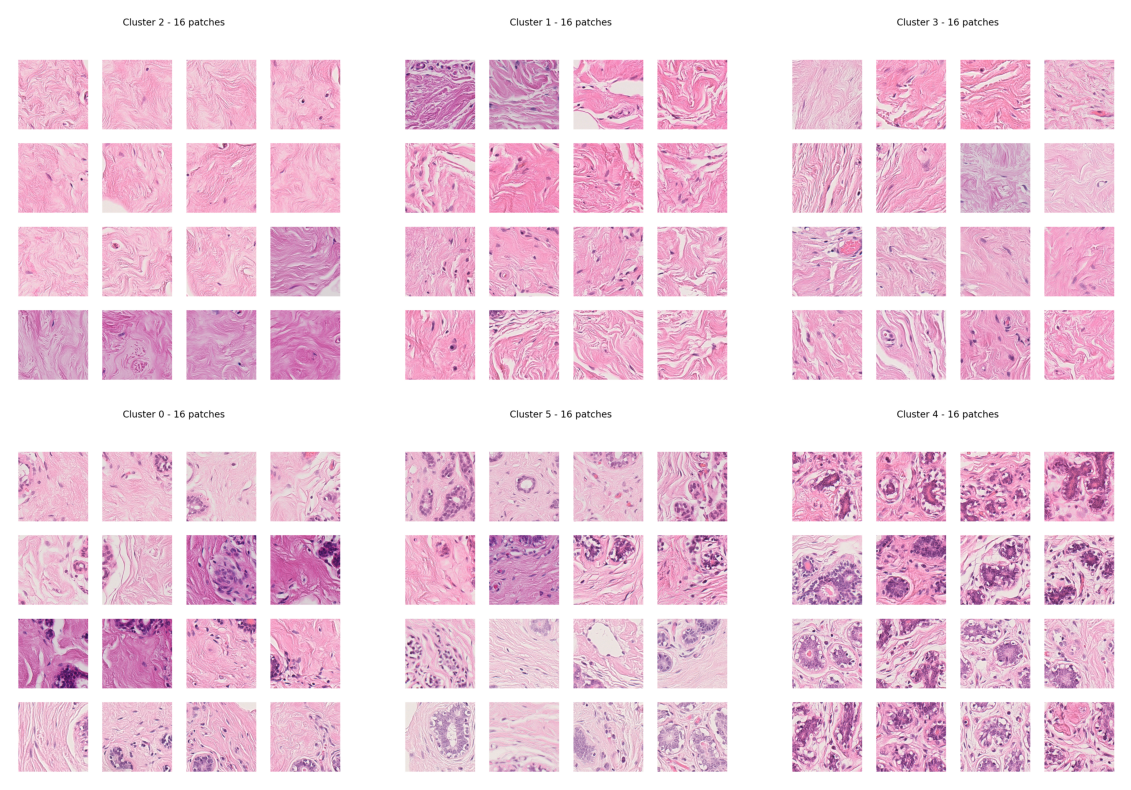

In [67]:
# Visualisation of the top H&E patches of each cluster
save_dir = f'{save_prefix}/{groupby}_patch_examples'
os.makedirs(save_dir, exist_ok=True)
for i, cluster_id in enumerate(np.unique(adata_normal.obs[groupby])):
    plot_cluster_examples(adata_normal, groupby, cluster_id, sampled_number=16, 
                          grid_size=[4, 4], figsize=(5, 5), fontsize=8, save_dir=save_dir, save_patches=False)
    

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cluster_id in enumerate([2,1,3,0,5,4]):
    row = idx // 3
    col = idx % 3
    img_path = os.path.join(save_dir, f"leiden_0.5_cluster{cluster_id}.png")
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    
plt.tight_layout()
save_pt = f'{save_prefix}/{groupby}_cluster_examples.png'
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# Sample random patches from each cluster
sys.path.append('/scratch/users/k21066795/BreastAgeNet')
from utils_model import parse_wsi_id
from utils_features import Reinhard
import stardist
import staintools
from stardist.models import StarDist2D
from stardist.plot import render_label
from csbdeep.utils import normalize

def get_xy(patch_id):
    try:
        x, y, patch_size = patch_id.split("_")[-3:]
        x, y, patch_size = int(x), int(y), int(patch_size)
        return x * patch_size, y * patch_size, patch_size
    except ValueError as e:
        raise ValueError(f"Invalid patch_id format: {patch_id}. Expected format '..._x_y_patch_size'.") from e


def crop_patch(image, x, y, patch_size=512):
    return image.crop((x, y, x + patch_size, y + patch_size))


WSIs = '/scratch_tmp/prj/cb_normalbreast/prj_BreastAgeNet/WSIs'
PATCH = f'{save_prefix}/{groupby}_HE'
os.makedirs(PATCH, exist_ok=True)

df = adata_normal.obs.copy()
patch_num = 3000
for cluster_id in range(6):
    patch_ids = list(df.loc[df[groupby] == cluster_id, "patch_id"])
    print(len(patch_ids))
    random.shuffle(patch_ids)
    
    for patch_id in patch_ids[:patch_num]:
        save_pt = f"{PATCH}/{patch_id}.tif"
        print(save_pt)

        if "BRACS" not in patch_id:
            wsi_id = parse_wsi_id(patch_id)
            try:
                wsi_path = glob.glob(f"{WSIs}/*/{wsi_id}*.*")[0]
                wsi = openslide.OpenSlide(wsi_path)
                x, y, patch_size = get_xy(patch_id)
                im = wsi.read_region((x, y), 0, (patch_size, patch_size)).convert("RGB")
            except Exception as e:
                print(f"Error processing WSI {wsi_id} for patch {patch_id}: {e}")
                continue  
        else:
            BRCAS = '/scratch_tmp/prj/cb_normalbreast/prj_BreastAgeNet/WSIs/BRACS_ROI'
            roi_id = "_".join(patch_id.split("_")[:-2])
            image_path = glob.glob(f"{BRCAS}/*/*/{roi_id}.png")[0] 
            image = Image.open(image_path)
            coordinates = patch_id.split('_')[-2:]  # Get the last two parts: x and y coordinates
            x, y = int(coordinates[0]), int(coordinates[1])
            im = crop_patch(image, x, y)

        # save the normalised patch
        patch_im_norm = Reinhard(np.array(im))
        patch_im_norm = Image.fromarray(patch_im_norm)
        patch_im_norm.save(save_pt)

In [ ]:
# StarDist nuclei segmentation of the sampled patches
NUCLEI = f'{save_prefix}/{groupby}_startdist'
os.makedirs(NUCLEI, exist_ok=True)
nuclei_csv = f"{save_prefix}/{groupby}_nuclei_morphology.csv"   # the file to save nuclei morphology quantification results

for patch_id in os.listdir(PATCH): 
    tar_pt = f'{NUCLEI}/{patch_id.replace(".tif", "_nu.tif")}'
    if not os.path.exists(tar_pt):
        try:
            print(tar_pt)
            patch_norm = Image.open(f"{PATCH}/{patch_id}")
            patch_im_norm = np.array(patch_norm)
            
            # apply StarDist to detect nuclei and save the mask
            model = StarDist2D.from_pretrained('2D_versatile_he')
            labels, details = model.predict_instances(normalize(patch_im_norm))
            seg_im = Image.fromarray(labels.astype(bool))
            seg_im.save(tar_pt)
            print(f"{tar_pt} saved!")
            # plot_contours(patch_im, details["coord"])
            
            # compute nuclei features
            nuclei_props_list = ["label", "area", "bbox_area", "extent", "eccentricity", "perimeter", "major_axis_length", "minor_axis_length", "solidity"]
            props = regionprops_table(labels, properties=nuclei_props_list)
            props_df = pd.DataFrame.from_dict(props)
            props_df["Circularity"] = (4*np.pi*props_df["area"]) / (props_df["major_axis_length"]**2)
            props_df["Elongation"] = props_df["major_axis_length"] / props_df["minor_axis_length"]
            props_df["patch_id"] = patch_id.split('.tif')[0]
            props_df["coord_x"] = details["points"][:,0]
            props_df["coord_y"] = details["points"][:,1]
            
            if not os.path.exists(nuclei_csv):
                props_df.to_csv(nuclei_csv, index=False)
            else:
                props_df.to_csv(nuclei_csv, mode="a", header=False, index=False)
        except:
            pass

In [101]:
# Aggregate nuclei-level morphology into patch-level table
nuclei_df = pd.read_csv(nuclei_csv)
nuclei_df = pd.merge(nuclei_df, adata_normal.obs.loc[:, ['patch_id', 'cohort', 'wsi_id', 'source', 'leiden_0.5']], on = 'patch_id')

agg_df = nuclei_df.groupby('patch_id').agg({
    'area': 'mean',
    'bbox_area': 'mean',
    'extent': 'mean',
    'eccentricity': 'mean',
    'perimeter': 'mean',
    'major_axis_length': 'mean',
    'minor_axis_length': 'mean',
    'solidity': 'mean',
    'Circularity': 'mean',
    'Elongation': 'mean',
    'patch_id': 'size',
    'cohort': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'wsi_id': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'source': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'leiden_0.5': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
}).rename(columns={
    'area': 'area_mean',
    'bbox_area': 'bbox_area_mean',
    'extent': 'extent_mean',
    'eccentricity': 'eccentricity_mean',
    'perimeter': 'perimeter_mean',
    'major_axis_length': 'major_axis_length_mean',
    'minor_axis_length': 'minor_axis_length_mean',
    'solidity': 'solidity_mean',
    'Circularity': 'circularity_mean',
    'Elongation': 'elongation_mean',
    'patch_id': 'nuclei_count'
}).reset_index()

agg_df.to_csv(f"{save_prefix}/{groupby}_nuclei_morphology_patchAggregate.csv", index=False)
agg_df.head()

,patch_id,area_mean,bbox_area_mean,extent_mean,eccentricity_mean,perimeter_mean,major_axis_length_mean,minor_axis_length_mean,solidity_mean,circularity_mean,elongation_mean,nuclei_count,cohort,wsi_id,source,leiden_0.5
0,17027148_FPE_1_33274_15932_8580_7424_58_36_578,435.666667,636.750000,0.682728,0.744726,79.756271,30.183980,18.317316,0.951935,5.980464,1.791736,12,KHP,17027148_FPE_1,N_RM,1
1,17027148_FPE_1_33274_15932_8580_7424_69_39_578,393.000000,565.666667,0.683787,0.809851,75.745863,28.951985,16.680905,0.948906,5.573351,1.727821,3,KHP,17027148_FPE_1,N_RM,2
2,17027148_FPE_2_12580_1986_92469_86893_100_80_555,795.000000,1050.000000,0.756404,0.859368,115.547727,45.988648,22.576476,0.946489,4.837108,2.096827,2,KHP,17027148_FPE_2,N_RM,2
3,17027148_FPE_2_12580_1986_92469_86893_105_90_555,515.000000,667.000000,0.772114,0.617495,83.012193,28.899565,22.731678,0.969868,7.748800,1.271334,1,KHP,17027148_FPE_2,N_RM,2
4,17027148_FPE_2_12580_1986_92469_86893_181_96_555,239.333333,398.666667,0.622276,0.916548,65.941125,28.244730,10.918448,0.940453,3.853194,2.598899,3,KHP,17027148_FPE_2,N_RM,2


In [106]:
# Pairwise comparison of nuclei morphology quantifications between phenotypes P0-P3 (Wilcoxon rank-sum test)
features = ['nuclei_count', 'area_mean', "perimeter_mean", "major_axis_length_mean", 
            "minor_axis_length_mean", "extent_mean", 'circularity_mean', 'elongation_mean', 
            "eccentricity_mean", "solidity_mean"]
save_pt = f"{save_prefix}/{groupby}_nuclei_pairwise_adj_pvalues.csv"
pval_df = compute_adjusted_pvalues(df=agg_df, features=features, 
                                   group_label="leiden_0.5", group_order = [0,1,2,3,4,5], save_pt=save_pt)
pval_df

,Feature,Group 1,Group 2,Adjusted p-value,Significance
0,nuclei_count,0,1,0.000000e+00,***
1,nuclei_count,0,2,0.000000e+00,***
2,nuclei_count,0,3,0.000000e+00,***
3,nuclei_count,0,4,1.249053e-197,***
4,nuclei_count,0,5,7.962569e-06,***
...,...,...,...,...,...
145,solidity_mean,2,4,0.000000e+00,***
146,solidity_mean,2,5,2.325794e-163,***
147,solidity_mean,3,4,0.000000e+00,***
148,solidity_mean,3,5,4.434714e-185,***


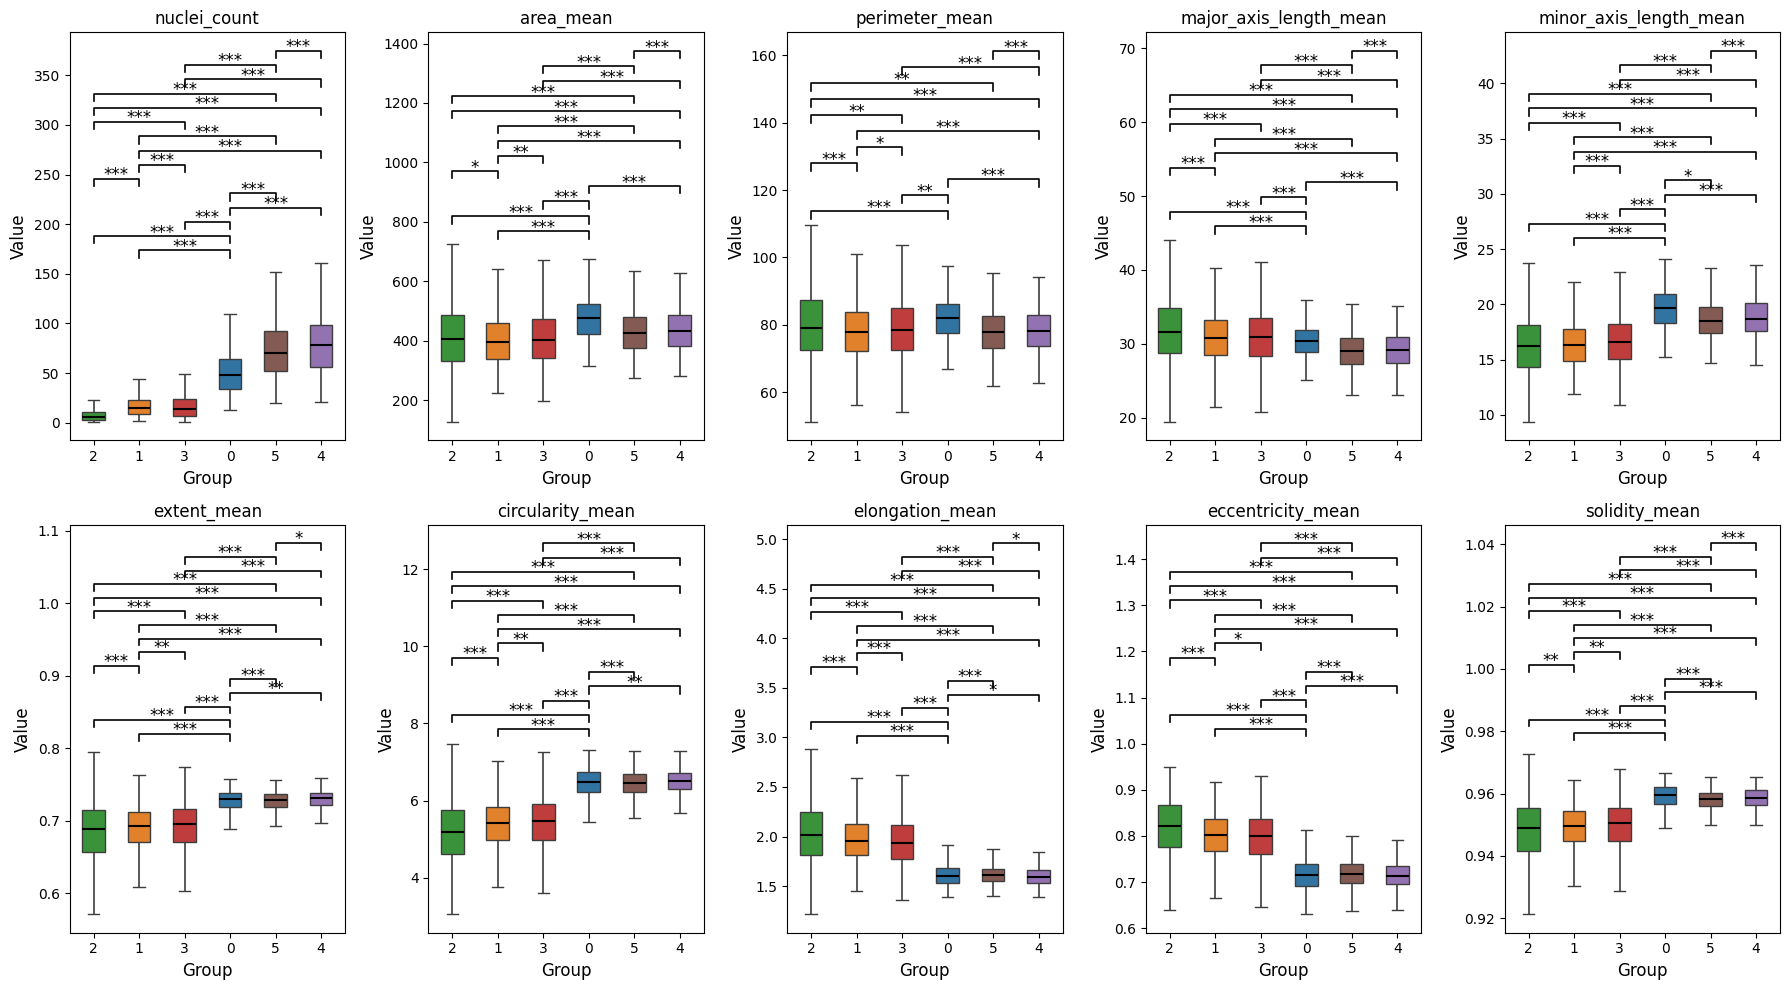

In [112]:
# Boxplot visualisation of pairwise comparison of nuclei morphology quantifications between phenotypes P0-P3 (Wilcoxon rank-sum test)
group_colors = {0: adata_normal.uns['leiden_0.5_colors'][0], 
          1: adata_normal.uns['leiden_0.5_colors'][1],
          2: adata_normal.uns['leiden_0.5_colors'][2],
          3: adata_normal.uns['leiden_0.5_colors'][3], 
          4: adata_normal.uns['leiden_0.5_colors'][4],
          5: adata_normal.uns['leiden_0.5_colors'][5]}


fig, axes = plt.subplots(2, 5, figsize=(18, 10))  
axes = axes.flatten()
for i, feature in enumerate(features):    
    boxplot_with_pvalue(agg_df, feature=feature, group_label="leiden_0.5", group_order=[2,1,3,0,5,4],
                        group_colors=group_colors, pval_df=pval_df, ax=axes[i], figsize=(12, 6), box_width=0.5)
plt.tight_layout()
save_pt = f"{save_prefix}/{groupby}_nuclei_adjust_pvalue_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0
patch_id,,,,,,,,,,,
17027148_FPE_2_12580_1986_92469_86893_99_91_555,17027148_FPE_2_12580_1986_92469_86893_99_91_555,KHP,17027148_FPE_2,N_RM,2,11.747646,6.762438,False,9,6,15
17027148_FPE_2_12580_1986_92469_86893_62_120_555,17027148_FPE_2_12580_1986_92469_86893_62_120_555,KHP,17027148_FPE_2,N_RM,3,11.986761,4.507391,False,9,6,13
17027148_FPE_2_12580_1986_92469_86893_104_90_555,17027148_FPE_2_12580_1986_92469_86893_104_90_555,KHP,17027148_FPE_2,N_RM,2,12.756907,8.744643,False,10,15,27
17027148_FPE_2_12580_1986_92469_86893_79_118_555,17027148_FPE_2_12580_1986_92469_86893_79_118_555,KHP,17027148_FPE_2,N_RM,3,11.095161,4.749600,False,9,6,13
17027148_FPE_2_12580_1986_92469_86893_150_148_555,17027148_FPE_2_12580_1986_92469_86893_150_148_555,KHP,17027148_FPE_2,N_RM,0,2.564113,2.191250,False,1,4,7
...,...,...,...,...,...,...,...,...,...,...,...
BRACS_773_N_33_768_0,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28
BRACS_773_N_33_768_256,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18
BRACS_773_N_33_1280_512,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,0,2.701497,2.551752,False,4,4,24


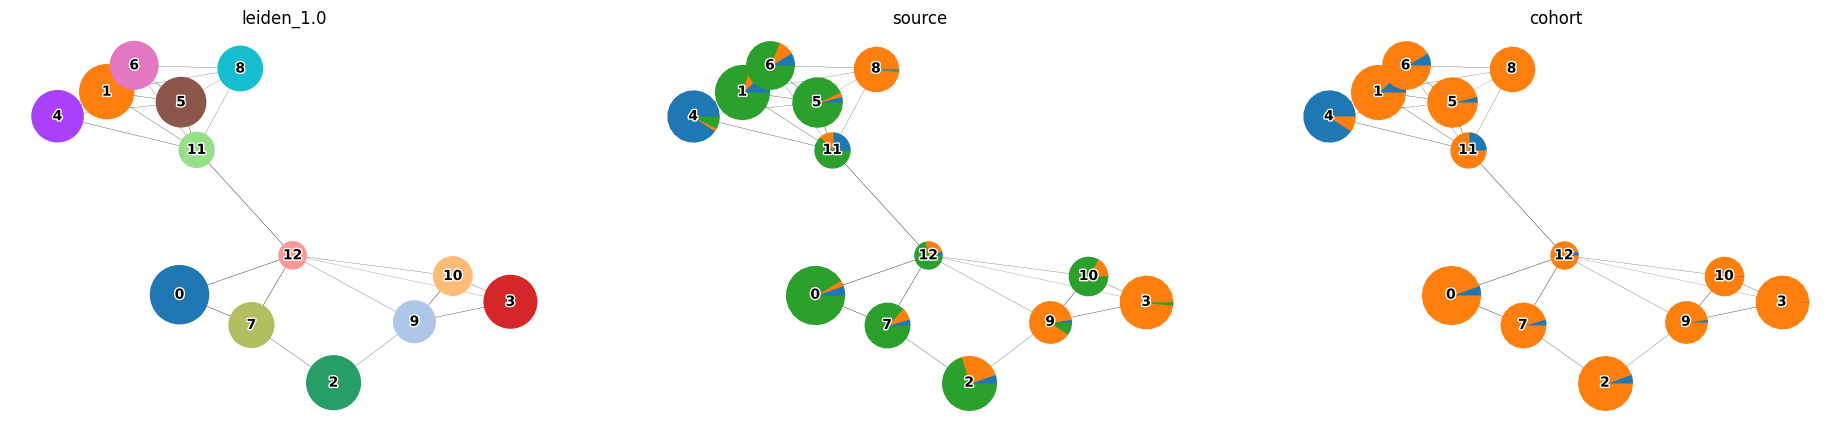

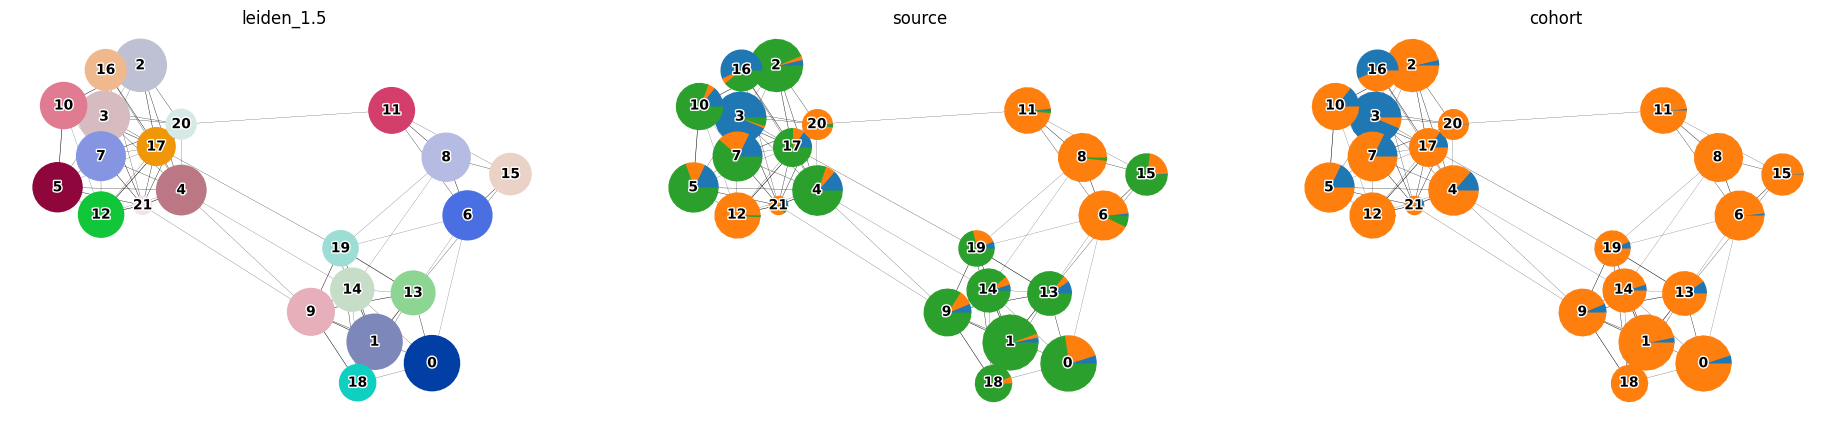

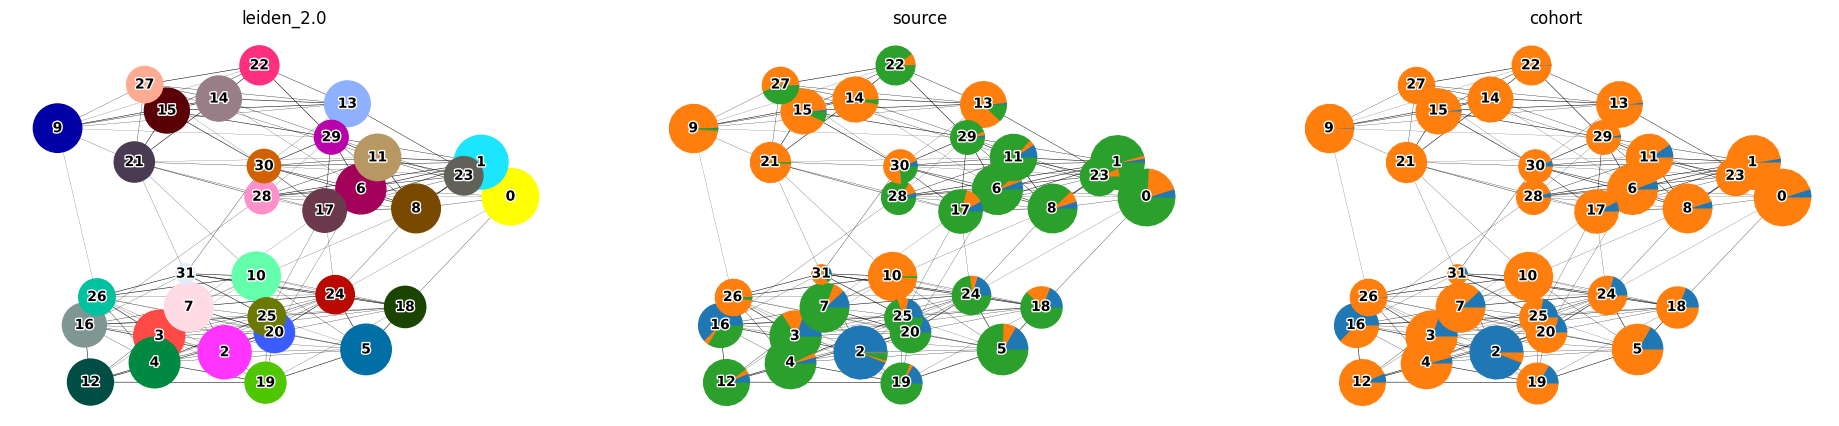

In [24]:
for resolution in [1.0, 1.5, 2.0]:
    adata_normal = run_leiden_umap(adata_normal, n_neighbors, resolution)

adata_normal.write(f'/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/adata/adata_NBTs_4levels.h5ad')
adata_normal.obs

In [8]:
# Clustree visualisation of relationships between phenotypes identified at different Leiden resolution 
import os
os.environ["R_HOME"] = "/scratch/users/k21066795/conda/miloR/lib/R"

import sys
sys.path.append('/scratch/users/k21066795/conda/miloR')
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')

import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging

rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [4]:
anndata2ri.activate()

/tmp/ipykernel_518701/4016445965.py:1: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [5]:
%load_ext rpy2.ipython

In [ ]:
%%R

library(clustree)
library(ggplot2)
options(scipen = 999)
library(scales)
library(tidyr)
library(pheatmap)

In [15]:
file_path = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)

leiden_columns = [col for col in adata_normal.obs.columns if 'top_samples' not in col]
data = adata_normal.obs.loc[:, leiden_columns]
data.columns = data.columns.str.replace('.', '', regex=False)
leiden_columns = [col for col in data.columns if col.startswith('leiden_')]
data[leiden_columns] = data[leiden_columns].apply(pd.to_numeric, errors='coerce')

In [12]:
%%R -i data

colnames(data)

 [1] "patient_id" "age"        "patch_id"   "cohort"     "wsi_id"    
 [6] "source"     "leiden_05"  "umap1"      "umap2"      "leiden_10" 
[11] "leiden_15"  "leiden_20"  "risk"      


Scale for edge_colour is already present.
Adding another scale for edge_colour, which will replace the existing scale.


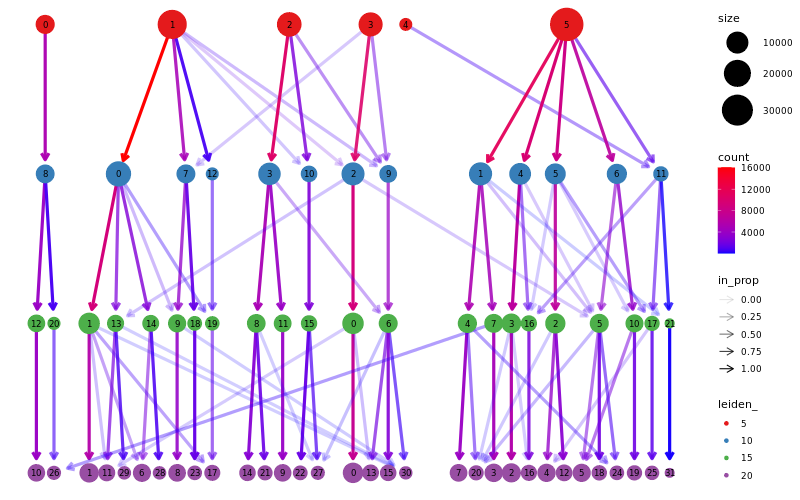

In [117]:
%%R -w 800 -h 500

data <- data.frame(
    leiden_05 = data$leiden_05,
    leiden_10 = data$leiden_10,
    leiden_15 = data$leiden_15,
    leiden_20 = data$leiden_20
)
p <- clustree(data, prefix = "leiden_") +
  scale_color_brewer(palette = "Set1") +
  scale_edge_color_continuous(low = "blue", high = "red")

ggsave("/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_atlas/NBTs_clustree_4levels.pdf", plot = p, width = 8, height = 5, device = "pdf")
p

In [16]:
data = data.reset_index(drop=True)  

file_path = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)
leiden_columns = [col for col in adata_normal.obs.columns if 'top_samples' not in col]
data = adata_normal.obs.loc[:, leiden_columns]
data.columns = data.columns.str.replace('.', '', regex=False)
leiden_columns = [col for col in data.columns if col.startswith('leiden_')]
data[leiden_columns] = data[leiden_columns].apply(pd.to_numeric, errors='coerce')

agg_df = pd.read_csv(f"/cephfs/volumes/hpc_data_prj/cb_microbiome/3d70379f-bb3a-4d40-9908-3b0496384f42/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_atlas/leiden_0.5_nuclei_morphology_patchAggregate.csv")

agg_df_leiden = pd.merge(agg_df, data, on='patch_id', how='left')
agg_df_leiden

,patch_id,area_mean,bbox_area_mean,extent_mean,eccentricity_mean,perimeter_mean,major_axis_length_mean,minor_axis_length_mean,solidity_mean,circularity_mean,...,cohort_y,wsi_id_y,source_y,leiden_05,umap1,umap2,leiden_10,leiden_15,leiden_20,risk
0,17027148_FPE_1_33274_15932_8580_7424_58_36_578,435.666667,636.750000,0.682728,0.744726,79.756271,30.183980,18.317316,0.951935,5.980464,...,KHP,17027148_FPE_1,N_RM,1,7.040086,9.286973,0,14,6,0
1,17027148_FPE_1_33274_15932_8580_7424_69_39_578,393.000000,565.666667,0.683787,0.809851,75.745863,28.951985,16.680905,0.948906,5.573351,...,KHP,17027148_FPE_1,N_RM,2,12.466032,7.988068,10,15,27,0
2,17027148_FPE_2_12580_1986_92469_86893_100_80_555,795.000000,1050.000000,0.756404,0.859368,115.547727,45.988648,22.576476,0.946489,4.837108,...,KHP,17027148_FPE_2,N_RM,2,11.808797,6.497365,9,6,15,0
3,17027148_FPE_2_12580_1986_92469_86893_105_90_555,515.000000,667.000000,0.772114,0.617495,83.012193,28.899565,22.731678,0.969868,7.748800,...,KHP,17027148_FPE_2,N_RM,2,12.109770,8.361293,10,15,27,0
4,17027148_FPE_2_12580_1986_92469_86893_181_96_555,239.333333,398.666667,0.622276,0.916548,65.941125,28.244730,10.918448,0.940453,3.853194,...,KHP,17027148_FPE_2,N_RM,2,10.952459,6.093318,9,6,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15390,BRACS_762_N_2_256_1024,318.695652,423.608696,0.753841,0.661133,65.824550,23.828278,16.982267,0.958852,7.109373,...,BRCAS,BRACS_762_N_2,N,3,4.707575,1.461277,1,5,18,2
15391,BRACS_762_N_2_256_256,287.913580,397.037037,0.733014,0.749787,63.879283,24.339661,14.999238,0.954105,6.201756,...,BRCAS,BRACS_762_N_2,N,5,2.778962,1.968275,1,7,3,2
15392,BRACS_773_N_33_1024_512,274.593023,376.267442,0.737896,0.686913,61.592039,22.759832,15.385053,0.955000,6.812176,...,BRCAS,BRACS_773_N_33,N,5,2.299118,3.228929,4,4,24,2
15393,BRACS_773_N_33_1536_256,270.870130,372.675325,0.733889,0.702952,61.010779,22.740114,15.093026,0.956082,6.691140,...,BRCAS,BRACS_773_N_33,N,5,-1.050461,3.728693,11,16,16,2


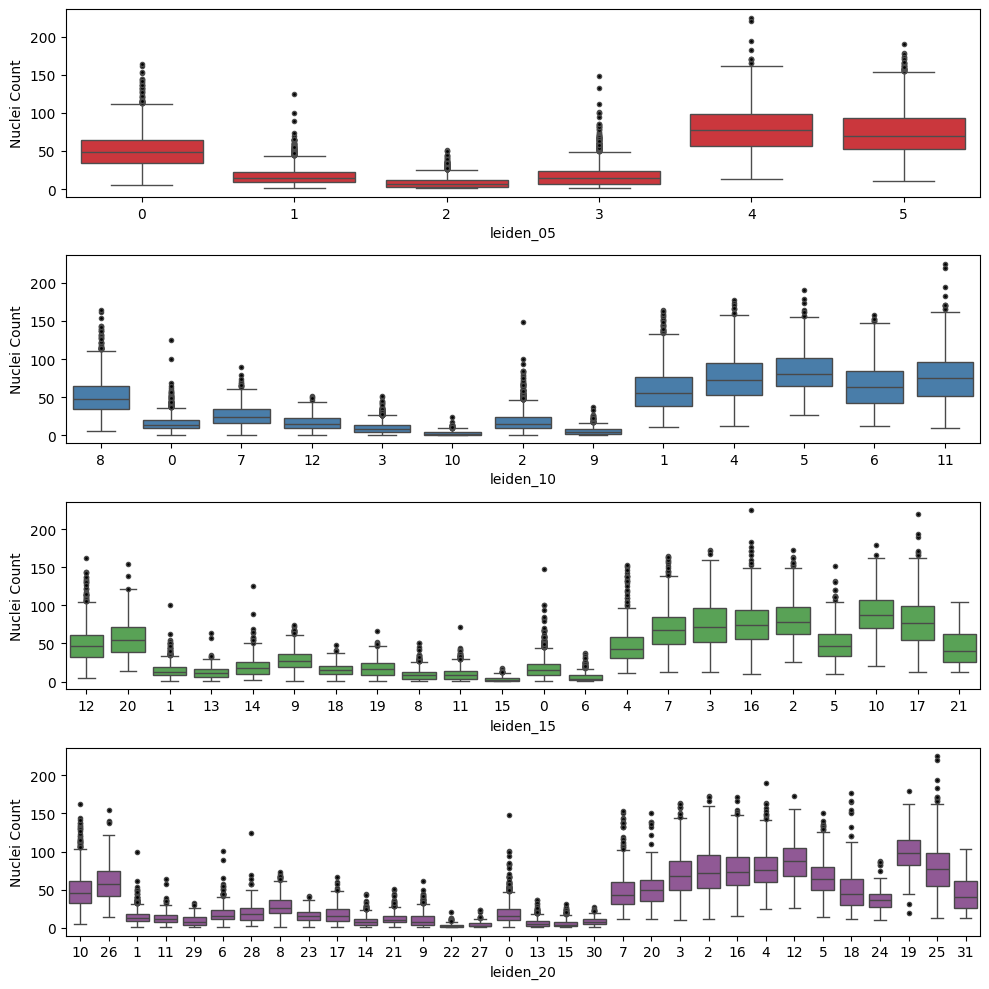

In [120]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

cluster_order_0 = ['0', '1', '2', '3', '4', '5']
cluster_order_1 = ['8', '0', '7', '12', '3', '10', '2', '9', '1', '4', '5', '6', '11']
cluster_order_2 = ['12', '20', '1', '13', '14', '9', '18', '19', '8', '11', '15', '0', '6', '4', '7', '3', '16', '2', '5', '10', '17', '21']
cluster_order_3 = ['10', '26', '1', '11', '29', '6', '28', '8', '23', '17', '14', '21', '9', '22', '27', '0', '13', '15', '30', '7', '20', '3', '2', '16', '4', '12', '5', '18', '24', '19', '25', '31']
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

sns.boxplot(x='leiden_05', y='nuclei_count', data=agg_df_leiden, order=cluster_order_0, ax=axes[0], color='#E21F26', flierprops=flierprops)
axes[0].set_ylabel('Nuclei Count', fontsize=10)

sns.boxplot(x='leiden_10', y='nuclei_count', data=agg_df_leiden, order=cluster_order_1, ax=axes[1], color='#397FB9', flierprops=flierprops)
axes[1].set_ylabel('Nuclei Count', fontsize=10)

sns.boxplot(x='leiden_15', y='nuclei_count', data=agg_df_leiden, order=cluster_order_2, ax=axes[2], color='#4EAF49', flierprops=flierprops)
axes[2].set_ylabel('Nuclei Count', fontsize=10)

sns.boxplot(x='leiden_20', y='nuclei_count', data=agg_df_leiden, order=cluster_order_3, ax=axes[3], color='#984F9F', flierprops=flierprops)
axes[3].set_ylabel('Nuclei Count', fontsize=10)

plt.tight_layout()
save_pt = f"{save_prefix}/{groupby}_nuclei_counts_4levels_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

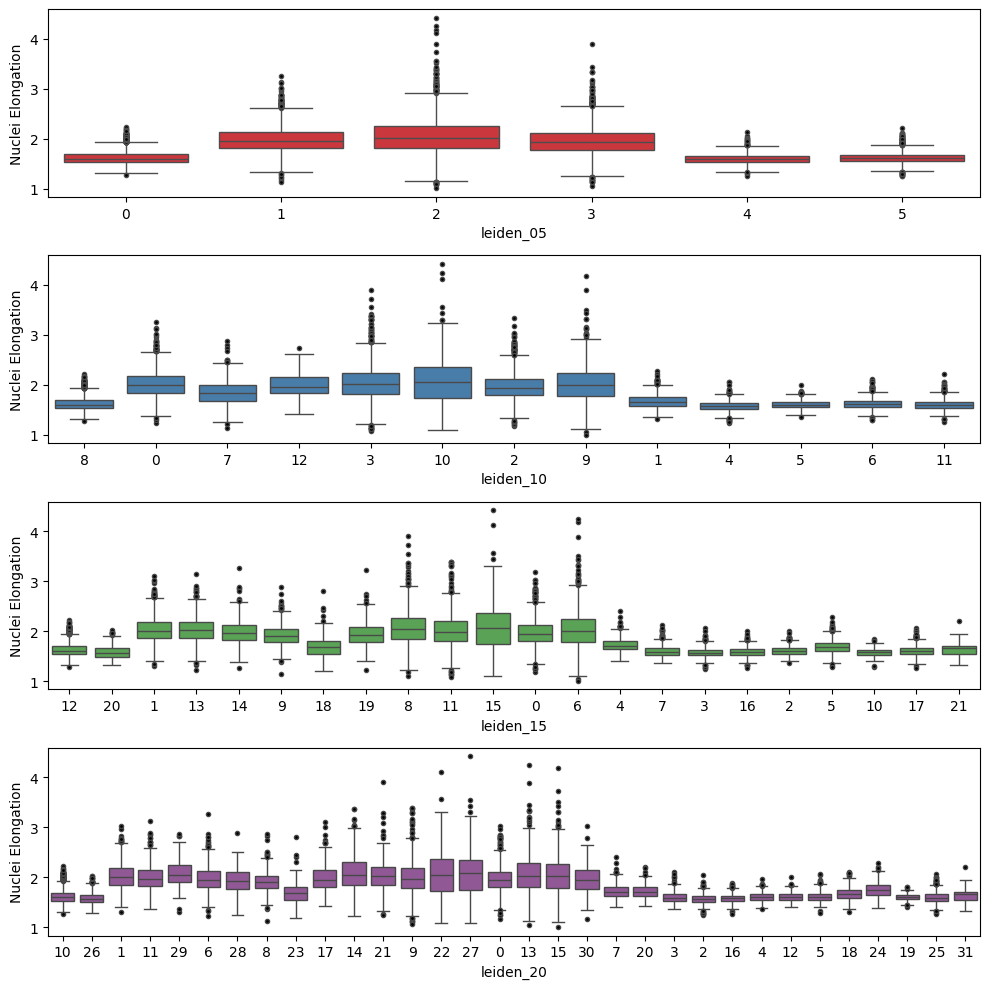

In [38]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10))

cluster_order_0 = ['0', '1', '2', '3', '4', '5']
cluster_order_1 = ['8', '0', '7', '12', '3', '10', '2', '9', '1', '4', '5', '6', '11']
cluster_order_2 = ['12', '20', '1', '13', '14', '9', '18', '19', '8', '11', '15', '0', '6', '4', '7', '3', '16', '2', '5', '10', '17', '21']
cluster_order_3 = ['10', '26', '1', '11', '29', '6', '28', '8', '23', '17', '14', '21', '9', '22', '27', '0', '13', '15', '30', '7', '20', '3', '2', '16', '4', '12', '5', '18', '24', '19', '25', '31']
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

sns.boxplot(x='leiden_05', y='elongation_mean', data=agg_df_leiden, order=cluster_order_0, ax=axes[0], color='#E21F26', flierprops=flierprops)
axes[0].set_ylabel('Nuclei Elongation', fontsize=10)

sns.boxplot(x='leiden_10', y='elongation_mean', data=agg_df_leiden, order=cluster_order_1, ax=axes[1], color='#397FB9', flierprops=flierprops)
axes[1].set_ylabel('Nuclei Elongation', fontsize=10)

sns.boxplot(x='leiden_15', y='elongation_mean', data=agg_df_leiden, order=cluster_order_2, ax=axes[2], color='#4EAF49', flierprops=flierprops)
axes[2].set_ylabel('Nuclei Elongation', fontsize=10)

sns.boxplot(x='leiden_20', y='elongation_mean', data=agg_df_leiden, order=cluster_order_3, ax=axes[3], color='#984F9F', flierprops=flierprops)
axes[3].set_ylabel('Nuclei Elongation', fontsize=10)

plt.tight_layout()
plt.show()

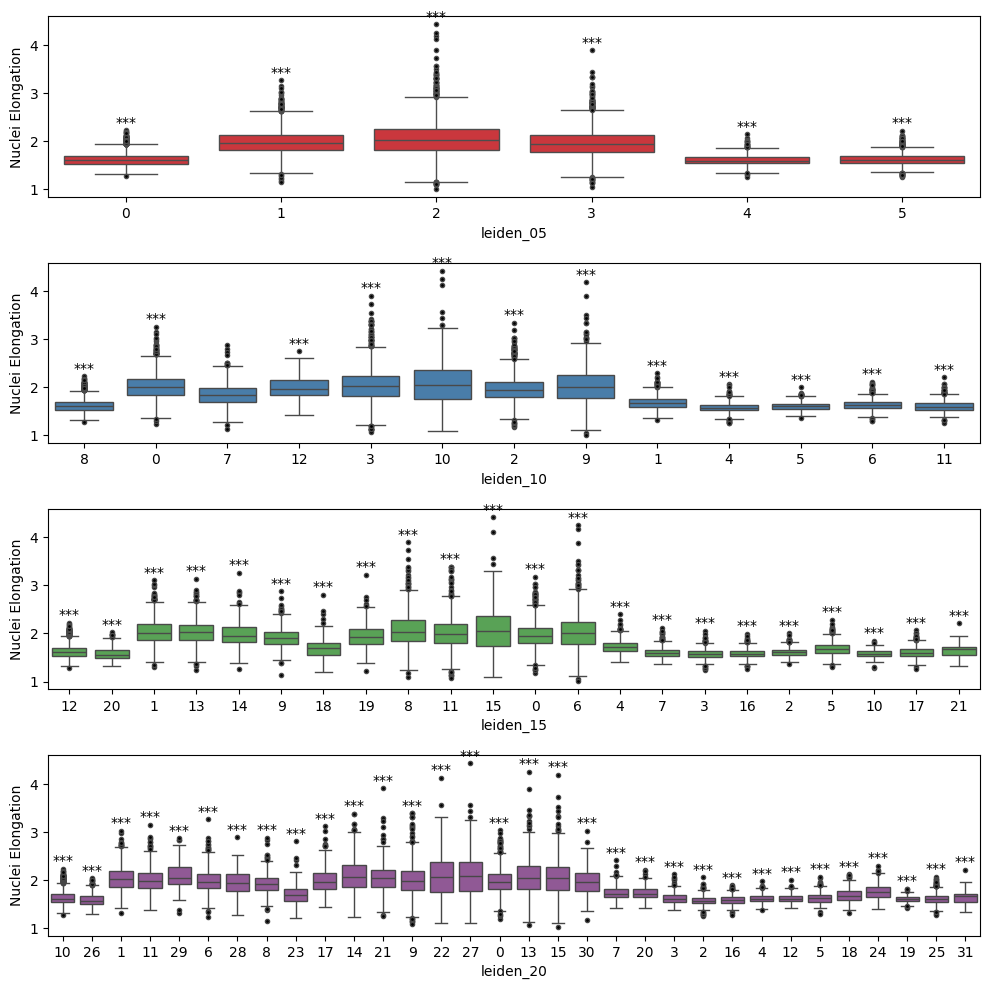

In [41]:

# Step 1: Compute overall mean
overall_mean = agg_df_leiden['elongation_mean'].mean()

# Store all cluster orders and column names for looping
cluster_levels = ['leiden_05', 'leiden_10', 'leiden_15', 'leiden_20']
cluster_orders = [cluster_order_0, cluster_order_1, cluster_order_2, cluster_order_3]
colors = ['#E21F26', '#397FB9', '#4EAF49', '#984F9F']

# Ensure that 'leiden_05', 'leiden_10', 'leiden_15', and 'leiden_20' are strings
agg_df_leiden['leiden_05'] = agg_df_leiden['leiden_05'].astype(str)
agg_df_leiden['leiden_10'] = agg_df_leiden['leiden_10'].astype(str)
agg_df_leiden['leiden_15'] = agg_df_leiden['leiden_15'].astype(str)
agg_df_leiden['leiden_20'] = agg_df_leiden['leiden_20'].astype(str)



fig, axes = plt.subplots(4, 1, figsize=(10, 10))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    sns.boxplot(x=level, y='elongation_mean', data=agg_df_leiden, order=order, ax=axes[i], color=color, flierprops=flierprops)
    axes[i].set_ylabel('Nuclei Elongation', fontsize=10)

    # Loop through each cluster and test vs overall mean
    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster]['elongation_mean']
        
        # Only perform test if more than one value
        if len(cluster_vals) > 1:
            tstat, pval = ttest_1samp(cluster_vals, overall_mean)
            # Define significance level
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            else:
                stars = ''
            if stars:
                # Get boxplot height (y) to position text
                y_max = cluster_vals.max()
                axes[i].text(j, y_max + 0.02, stars, ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()
